# Exploratory Data Analysis (EDA) - Sampled Data

In this notebook, we explore the **Amazon Recommendation** and **H&M Personalized Fashion** datasets.

## Optimized Setup
Per your request, we are skipping the massive 30GB+ image downloads for H&M by streaming to exactly 1M rows using the Kaggle API Token. For **Amazon**, we are pointing directly to the dataset you extracted in the local `data/raw/amazon/` folder (`train_data_prepared.parquet` and `test-Amazon-C4.csv`).

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import requests
from tqdm import tqdm
import zipfile

# Set rich plotting style
sns.set_theme(style="darkgrid", palette="deep")
plt.rcParams.update({'figure.figsize': (10, 6)})
warnings = __import__('warnings')
warnings.filterwarnings('ignore')

### 1. Load Pre-Extracted Amazon Dataset
Reading securely from your `data/raw/amazon/` directory.

In [6]:
amazon_dir = "../data/raw/amazon"

try:
    print("Loading Amazon Training Data (Parquet)...")
    amazon_train = pd.read_parquet(os.path.join(amazon_dir, 'train_data_prepared.parquet'), engine='pyarrow')
    # We sample it to 1 Million max to stay consistent
    if len(amazon_train) > 1000000:
        amazon_train = amazon_train.sample(1000000, random_state=42)
    
    print("Loading Amazon Test Data (CSV)...")
    amazon_test = pd.read_csv(os.path.join(amazon_dir, 'test-Amazon-C4.csv'))
    
    print(f"Loaded! Train: {amazon_train.shape}, Test: {amazon_test.shape}")
except Exception as e:
    print("Failed to load Amazon data. Make sure it's in the `data/raw/amazon/` directory.")
    print(f"Error: {e}")

Loading Amazon Training Data (Parquet)...
Loading Amazon Test Data (CSV)...
Loaded! Train: (1000000, 2), Test: (21223, 6)


### 2. Download & Sample H&M Datasets using Kaggle API Token
We stream the downloads, read only the first 1 Million rows directly from the archives, and save lightweight datasets.

In [7]:
data_dir = "../data/raw"
os.makedirs(data_dir, exist_ok=True)

API_TOKEN = "KGAT_25f671037349b751e0c17ee91997c595"
headers = {'Authorization': f'Bearer {API_TOKEN}'}

def download_kaggle_file(url, dest_path):
    if os.path.exists(dest_path):
        print(f"File {dest_path} already exists. Skipping download.")
        return
    print(f"Starting download to {dest_path}...")
    with requests.get(url, headers=headers, stream=True) as r:
        if r.status_code == 403:
             print("HTTP 403 Forbidden: Ensure you have accepted the competition rules on Kaggle for H&M!")
        r.raise_for_status()
        total_size = int(r.headers.get('content-length', 0))
        with open(dest_path, 'wb') as f, tqdm(total=total_size, unit='iB', unit_scale=True) as pbar:
            for chunk in r.iter_content(chunk_size=8192):
                if chunk:
                    size = f.write(chunk)
                    pbar.update(size)
    print("Download Complete!")

In [8]:
# Download ONLY Specific H&M Files (Skipping 30GB of images)
hm_transactions_url = "https://www.kaggle.com/api/v1/competitions/data/download/h-and-m-personalized-fashion-recommendations/transactions_train.csv"
hm_articles_url = "https://www.kaggle.com/api/v1/competitions/data/download/h-and-m-personalized-fashion-recommendations/articles.csv"

hm_transactions_zip = os.path.join(data_dir, "transactions_train.csv.zip")
hm_articles_zip = os.path.join(data_dir, "articles.csv.zip")

download_kaggle_file(hm_transactions_url, hm_transactions_zip)
download_kaggle_file(hm_articles_url, hm_articles_zip)

hm_trans_sampled_path = os.path.join(data_dir, "hm_transactions_sampled.csv")
if not os.path.exists(hm_trans_sampled_path):
    print("Sampling H&M Transactions directly from Zip (1M rows max)...")
    hm_transactions = pd.read_csv(hm_transactions_zip, compression='zip', nrows=1000000)
    hm_transactions.to_csv(hm_trans_sampled_path, index=False)
    print(f"Saved 1 Million row sample to {hm_trans_sampled_path}")
else:
    print("H&M transactions sample exists.")
    hm_transactions = pd.read_csv(hm_trans_sampled_path)

hm_articles_path = os.path.join(data_dir, "hm_articles_sampled.csv")
if not os.path.exists(hm_articles_path):
    print("Reading H&M Articles...")
    hm_articles = pd.read_csv(hm_articles_zip, compression='zip', nrows=1000000)
    hm_articles.to_csv(hm_articles_path, index=False)
else:
    print("H&M Articles sample exists.")
    hm_articles = pd.read_csv(hm_articles_path)

File ../data/raw\transactions_train.csv.zip already exists. Skipping download.
File ../data/raw\articles.csv.zip already exists. Skipping download.
H&M transactions sample exists.
H&M Articles sample exists.


---

## 3. In-Depth Exploratory Data Analysis (EDA)
Now that both datasets are loaded efficiently, let's explore their schemas, semantic text bounds, and user behaviors.

### A. Amazon Recommender Data Analytics

In [9]:
print("Amazon Test Sets Schema (Original Reviews vs Queries):")
display(amazon_test[['query', 'ori_rating', 'ori_review']].head(3))

print("\nAmazon Train Sets Schema (Queries & Documents for text-based retrieval):")
display(amazon_train.head(3))

Amazon Test Sets Schema (Original Reviews vs Queries):


,query,ori_rating,ori_review
0,I need filters that effectively trap dust and ...,5,These filters work I could not believe the amo...
1,I need to find a protein that is super healthy...,5,Love We love this protein we’ve been using it ...
2,I need a pillow that helps keep my nasal pillo...,5,CPAP help I use this pillow nightly with my CP...



Amazon Train Sets Schema (Queries & Documents for text-based retrieval):


,query_text,doc_text
39070,I really liked these earrings. I got them beca...,Queen Jewelers Sterling Silver Black Cubic Zir...
1158022,Looks great! Love it!,Pyjacos Womens Knit Winter Beanie Hat Faux Fur...
267770,Great fit. Very durable quality,Coofandy Men's Casual Short Sleeve T-shirt Con...


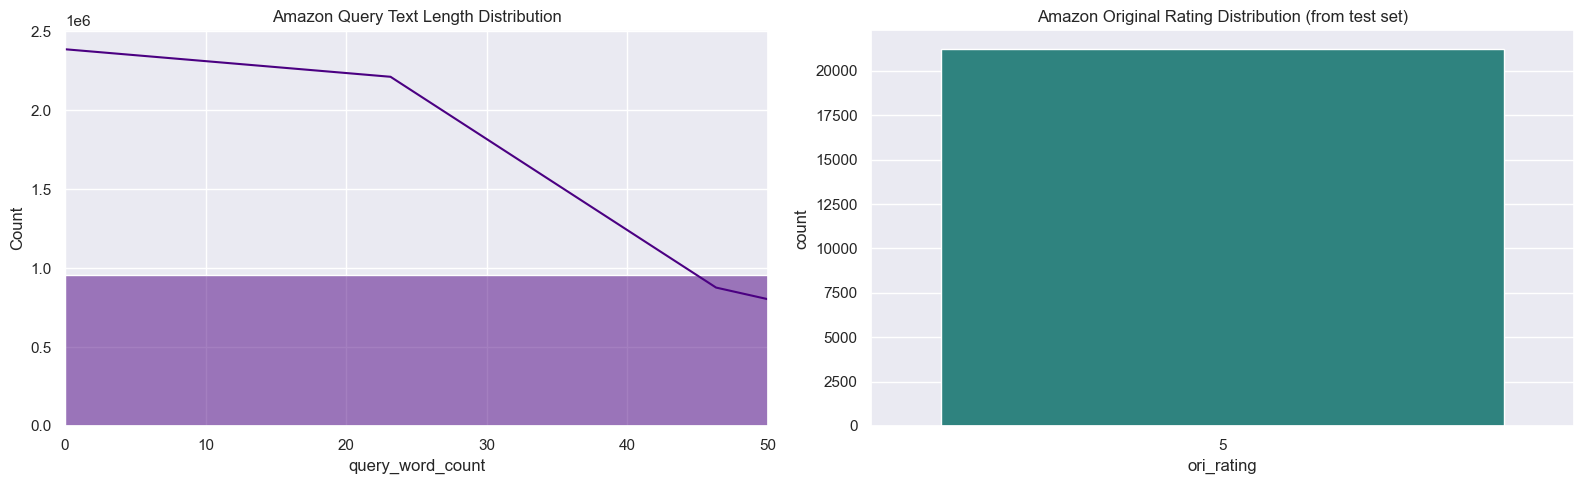

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Average Query Length
amazon_train['query_word_count'] = amazon_train['query_text'].apply(lambda x: len(str(x).split()))
sns.histplot(amazon_train['query_word_count'], bins=30, ax=axes[0], color='indigo', kde=True)
axes[0].set_title('Amazon Query Text Length Distribution')
axes[0].set_xlim(0, 50)

# Actual User Original Ratings (If rating skewed, predictions should be weighted)
if 'ori_rating' in amazon_test.columns:
    sns.countplot(x='ori_rating', data=amazon_test, ax=axes[1], palette='viridis')
    axes[1].set_title('Amazon Original Rating Distribution (from test set)')

plt.tight_layout()
plt.show()

**Observation**: The Amazon dataset contains fully processed semantic arrays. This means the `[query_text]` directly maps to textual `[doc_text]`. This is absolutely perfect for the **Natural Language** element of our LLM Hybrid recommender!

---

### B. H&M Fashion Data Analytics

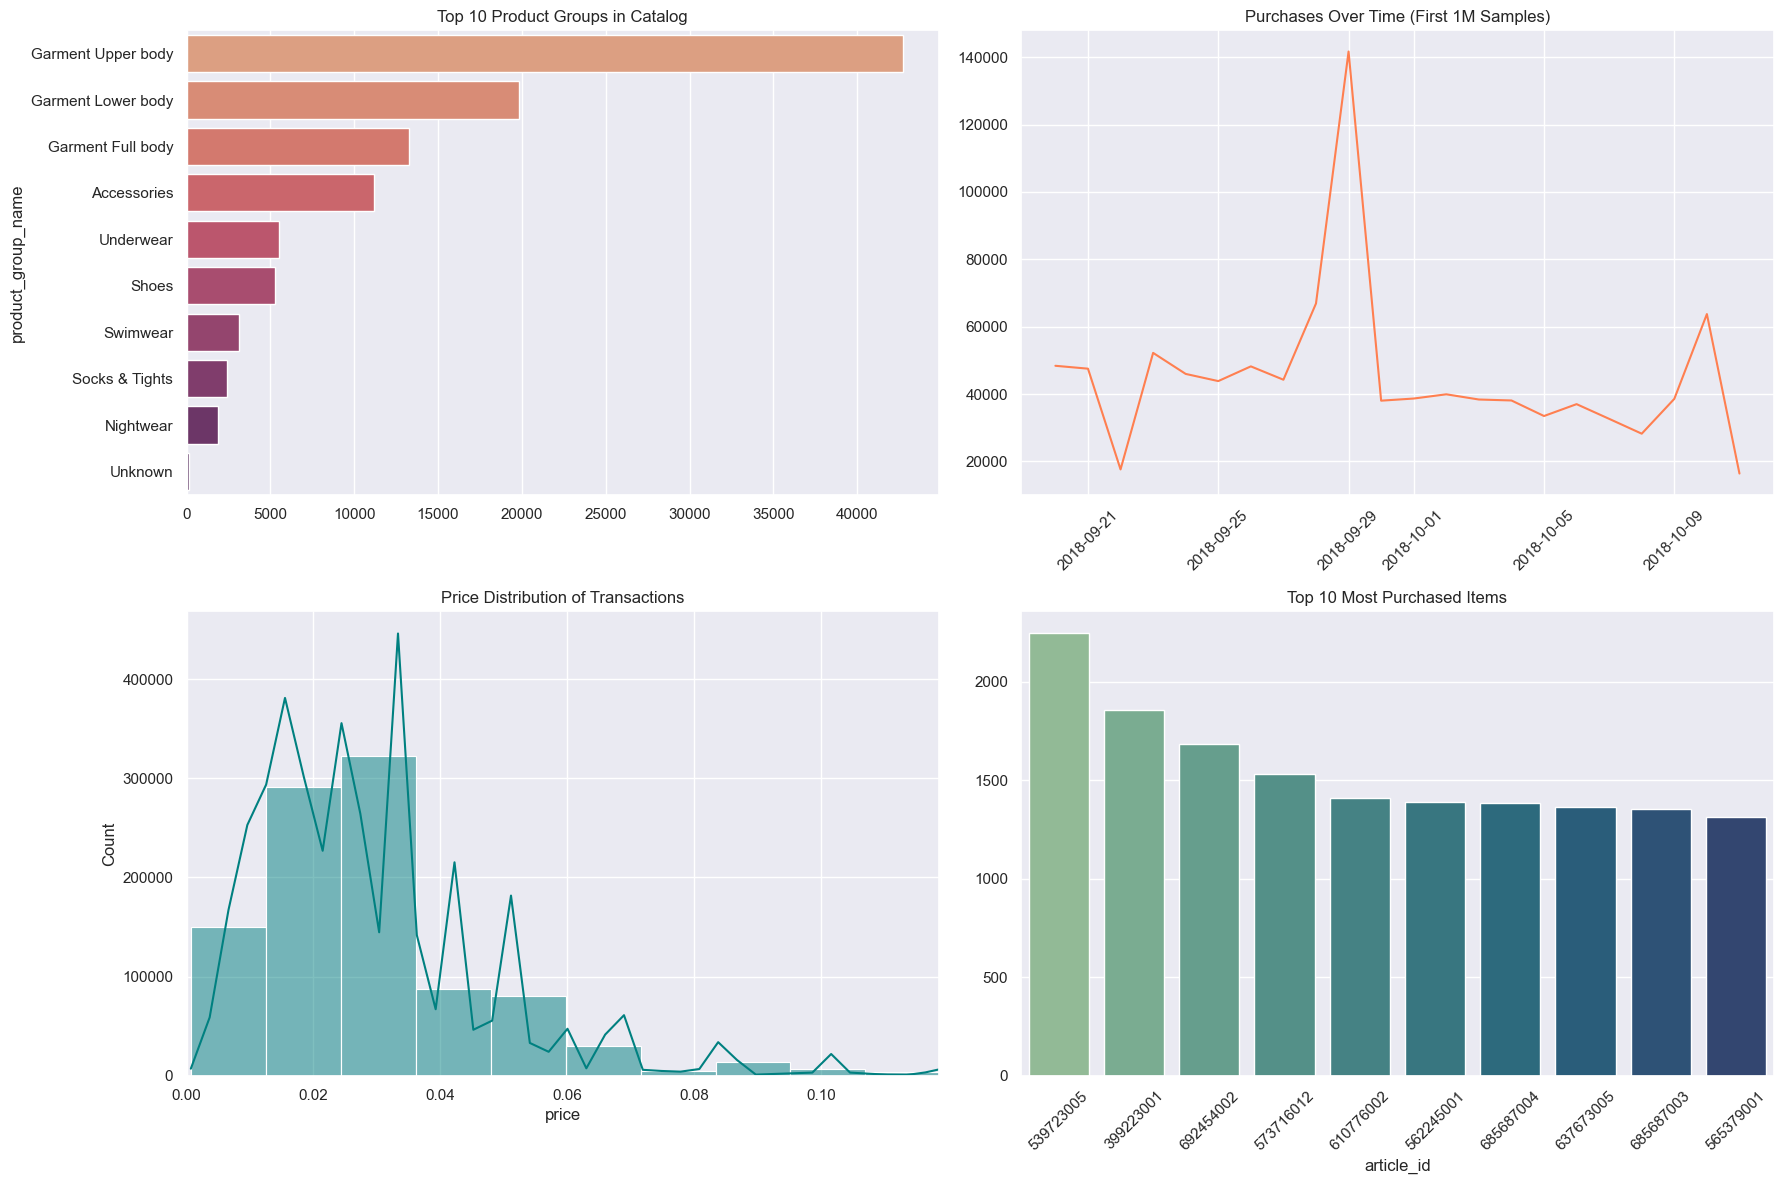

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# 1. Most common product groups in catalog
top_groups = hm_articles['product_group_name'].value_counts().head(10)
sns.barplot(y=top_groups.index, x=top_groups.values, ax=axes[0, 0], palette='flare')
axes[0, 0].set_title('Top 10 Product Groups in Catalog')

# 2. Transactions Over Time
try:
    hm_transactions['t_dat'] = pd.to_datetime(hm_transactions['t_dat'])
    daily_sales = hm_transactions.groupby(hm_transactions['t_dat'].dt.date)['article_id'].count()
    axes[0, 1].plot(daily_sales.index, daily_sales.values, color='coral')
    axes[0, 1].set_title('Purchases Over Time (First 1M Samples)')
    axes[0, 1].tick_params(axis='x', rotation=45)
except KeyError:
    pass # If schema varies

# 3. Price Distribution
sns.histplot(hm_transactions['price'], bins=50, ax=axes[1, 0], color='teal', kde=True)
axes[1, 0].set_title('Price Distribution of Transactions')
axes[1, 0].set_xlim(0, hm_transactions['price'].quantile(0.99))

# 4. Most Popular Items Purchased
top_item_sales = hm_transactions['article_id'].value_counts().head(10)
sns.barplot(x=top_item_sales.index.astype(str), y=top_item_sales.values, ax=axes[1, 1], palette='crest')
axes[1, 1].set_title('Top 10 Most Purchased Items')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

**Observation**: Fashion purchases tend to have intense spikes around seasons/events, visible on the timeline. Also, `article_id` is extremely skewed - some items sell hundreds of times, while thousands sell only once. This means we must engineer "Item Popularity" as a core feature inside our **LightGBM Ranker**!